In [1]:
from pathlib import Path
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / ".projectroot").exists())

# UN GA Voting Alignment : EDA + Preparation

The Bailey-Strezhnev-Voeten ideal points summarize how countries vote in the UN General Assembly, placing each on a Western to anti-Western foreign-policy axis.

**Input:** `data/raw/ungavoting/Idealpointestimates1946-2025.tab` (ideal points) and `AgreementScores.csv` (pairwise vote agreement).
**Output:** `data/interim/ungavoting/ungavoting_clean.csv` (one row per country-year, keyed on ISO3).

## 1. Setup and Load

I import the libraries, set the raw and output paths, and define the two poles I score agreement against, the US and Russia (365).

In [2]:
import os
import numpy as np
import pandas as pd

RAW = str(ROOT / "data/raw/ungavoting")
OUT_DIR = str(ROOT / "data/interim/ungavoting")
POLES = {2: 'agree_us', 365: 'agree_rus'}
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 170)

I set one consistent, high-resolution style for every chart (resolution, fonts, sizes, colors).

In [3]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 130, 'savefig.dpi': 200,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.titlesize': 14, 'axes.titleweight': 'bold', 'axes.labelsize': 12,
    'axes.edgecolor': '#444444', 'axes.linewidth': 0.8,
    'axes.grid': True, 'grid.color': '#E9E9E9', 'grid.linewidth': 0.8,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False, 'legend.frameon': False,
})
NAVY, BLUE, RED = '#1F3864', '#2E75B6', '#C0392B'

I load the ideal-point file (the core alignment measure), keep 2015 onward, select the ideal point and vote count, and build a ccode-to-ISO3 map I will need to join the agreement scores (which are keyed on COW country codes).

In [4]:
ip = pd.read_csv(f'{RAW}/Idealpointestimates1946-2025.tab', sep='\t',
                 usecols=['ccode', 'iso3c', 'Countryname', 'year', 'NVotesFP', 'IdealPointFP'])
cmap = ip.dropna(subset=['ccode', 'iso3c']).drop_duplicates('ccode').set_index('ccode')['iso3c'].to_dict()
ip = ip[ip['year'] >= 2015].rename(columns={'iso3c': 'iso3', 'Countryname': 'country',
                                            'IdealPointFP': 'ideal_point', 'NVotesFP': 'n_votes'})
ip = ip[['iso3', 'country', 'year', 'ideal_point', 'n_votes']]
print('ideal points 2015+ ->', ip.shape, '| countries:', ip['iso3'].nunique(), '| years:', ip['year'].min(), '-', ip['year'].max())
ip.head(3)

ideal points 2015+ -> (2115, 5) | countries: 193 | years: 2015 - 2025


,iso3,country,year,ideal_point,n_votes
68,USA,United States,2015,2.446909,78
69,USA,United States,2016,2.428575,80
70,USA,United States,2017,2.547005,93


The ideal-point file gives 2,115 country-years across 193 countries for 2015 to 2025, nearly every UN member. The USA is high (2.45).

## 2. Data Discovery

First I look at the ideal-point rows to see what each row holds.

In [5]:
ip.head()

,iso3,country,year,ideal_point,n_votes
68,USA,United States,2015,2.446909,78
69,USA,United States,2016,2.428575,80
70,USA,United States,2017,2.547005,93
71,USA,United States,2018,2.694519,109
72,USA,United States,2019,2.572579,100


`ip` = one row per country per year.

- Each row = a country in a year, with its alignment (ideal_point) and how many votes it cast (n_votes).
- Example (first row): the USA in 2015 had ideal_point 2.45 (the Western pole) from 78 roll-call votes.
- The other raw file, AgreementScores, is different: one row per country-pair per year (how often two countries voted the same), which I load next.

Before using the agreement file, I look at its raw rows to see what each one holds.

In [6]:
pd.read_csv(f'{RAW}/AgreementScores.csv', nrows=5)

,Unnamed: 0,session.x,ccode1,ccode2,agree,year,IdealPointFP.x,NVotesFP.x,IdealPointFP.y,NVotesFP.y,IdealPointDistance
0,1,1,2,20,0.868421,1946,1.663375,25,2.055612,24,0.392237
1,2,1,2,40,0.743243,1946,1.663375,25,1.210834,25,0.452541
2,3,1,2,41,0.500000,1946,1.663375,25,-0.205380,12,1.868755
3,4,1,2,42,0.723684,1946,1.663375,25,1.213540,24,0.449835
4,5,1,2,70,0.597222,1946,1.663375,25,0.643123,25,1.020252


`AgreementScores` = one row per country pair per year.

- Key columns: ccode1 and ccode2 are the two countries (COW codes), year, and agree (share of votes where they voted the same, 0 to 1). It also carries each side's ideal point and their IdealPointDistance, which I do not need.
- Example (first row): ccode1 2 (USA) and ccode2 20 (Canada) in 1946 with agree 0.87 means the US and Canada voted alike 87% of the time.
- I only need each country's agreement with the poles, so next I filter ccode2 to the US and Russia and pivot to one row per country-year.

I load the agreement scores (how often two countries vote the same way) and keep each country's agreement with the US, Russia, and China.

In [7]:
AUDIT = {2: 'agree_us', 365: 'agree_rus', 710: 'agree_chn'}
ag = pd.read_csv(f'{RAW}/AgreementScores.csv', usecols=['ccode1', 'ccode2', 'year', 'agree'])
ag = ag[(ag['year'] >= 2015) & (ag['ccode2'].isin(AUDIT))].copy()
ag['pole'] = ag['ccode2'].map(AUDIT)
piv = ag.pivot_table(index=['ccode1', 'year'], columns='pole', values='agree').reset_index()
piv['iso3'] = piv['ccode1'].map(cmap)
piv = piv.dropna(subset=['iso3'])
print('agreement pivot ->', piv.shape, '| countries:', piv['iso3'].nunique())
piv.head(3)

agreement pivot -> (1926, 6) | countries: 193


pole,ccode1,year,agree_chn,agree_rus,agree_us,iso3
0,2,2015,0.329787,0.415789,NaN,USA
1,2,2016,0.390756,0.418103,NaN,USA
2,2,2017,0.309524,0.350394,NaN,USA


The agreement pivot gives 1,926 country-years across 193 countries, one column per pole.

I merge the ideal point with the three agreement columns and check both coverage and redundancy among the candidates, to confirm which features to keep. 

In [8]:
cand = ip.merge(piv[['iso3', 'year', 'agree_us', 'agree_rus', 'agree_chn']], on=['iso3', 'year'], how='left')
cols = ['ideal_point', 'agree_us', 'agree_rus', 'agree_chn']
print('coverage %:', (cand[cols].notna().mean() * 100).round(1).to_dict())
cand[cols].corr(method='spearman').round(2)

coverage %: {'ideal_point': 100.0, 'agree_us': 90.5, 'agree_rus': 90.5, 'agree_chn': 90.5}


,ideal_point,agree_us,agree_rus,agree_chn
ideal_point,1.00,0.76,-0.65,-0.80
agree_us,0.76,1.00,-0.75,-0.81
agree_rus,-0.65,-0.75,1.00,0.87
agree_chn,-0.80,-0.81,0.87,1.00


The US and Russia agreements add distinct signal: agree_us correlates 0.76 with the ideal point and agree_rus -0.65, and the two correlate negatively -0.75 with each other, all comfortably below the 0.90 bar, so they stay. agree_chn correlates 0.87 with agree_rus and -0.80 / -0.81 with the ideal point and agree_us, which makes it redundant.

## 3. Data Preparation

I merge the ideal point with each country's agreement with the US and Russia, keep the vote count, and drop agree_chn (redundant with agree_rus). This gives 4 alignment features per country-year, keyed on ISO3.

In [9]:
unga = ip.merge(piv[['iso3', 'year', 'agree_us', 'agree_rus']], on=['iso3', 'year'], how='left')
unga = (unga[['iso3', 'year', 'ideal_point', 'agree_us', 'agree_rus', 'n_votes']]
        .sort_values(['iso3', 'year']).reset_index(drop=True))
print('unga ->', unga.shape, '| countries:', unga.iso3.nunique(), '| years:', unga.year.min(), '-', unga.year.max())
unga[unga.iso3.isin(['USA', 'RUS', 'UKR', 'IRN']) & (unga.year == 2023)]

unga -> (2115, 6) | countries: 193 | years: 2015 - 2025


,iso3,year,ideal_point,agree_us,agree_rus,n_votes
874,IRN,2023,-1.402609,0.241150,0.792453,84
1611,RUS,2023,-0.270707,0.252294,NaN,88
1973,UKR,2023,1.183105,0.849558,0.356132,87
1995,USA,2023,2.264812,NaN,0.252294,88


The clean table is 2,115 country-years across 193 countries, 2015 to 2025, with 4 features.

## 4. Exploratory Data Analysis

I load the GPR target and join it to the alignment features, and rank them by Spearman correlation with GPR.

In [10]:
gpr = pd.read_csv(str(ROOT / "data/interim/gpr/gpr_monthly.csv"))
gpr['year'] = pd.to_datetime(gpr['month']).dt.year
target = gpr[(gpr.year >= 2015) & (gpr.year <= 2023)].groupby(['iso3', 'year'])['gpr'].mean().reset_index()

feats = ['ideal_point', 'agree_us', 'agree_rus', 'n_votes']
ms = unga.merge(target, on=['iso3', 'year'], how='inner')
print('labeled country-years:', len(ms), '| countries:', ms.iso3.nunique())
ms[feats + ['gpr']].corr(method='spearman')['gpr'].drop('gpr').sort_values(ascending=False).to_frame('spearman_with_gpr').round(3)

labeled country-years: 376 | countries: 42


,spearman_with_gpr
ideal_point,0.416
agree_us,0.317
n_votes,0.005
agree_rus,-0.245


Across 376 labeled country-years (42 countries) ideal_point is the most GPR-correlated feature (0.42, positive).

I rank the most pro-Western and most anti-Western countries by mean ideal_point, and I highlight Russia and China in orange so I can see where the two great powers sit relative to the extremes.

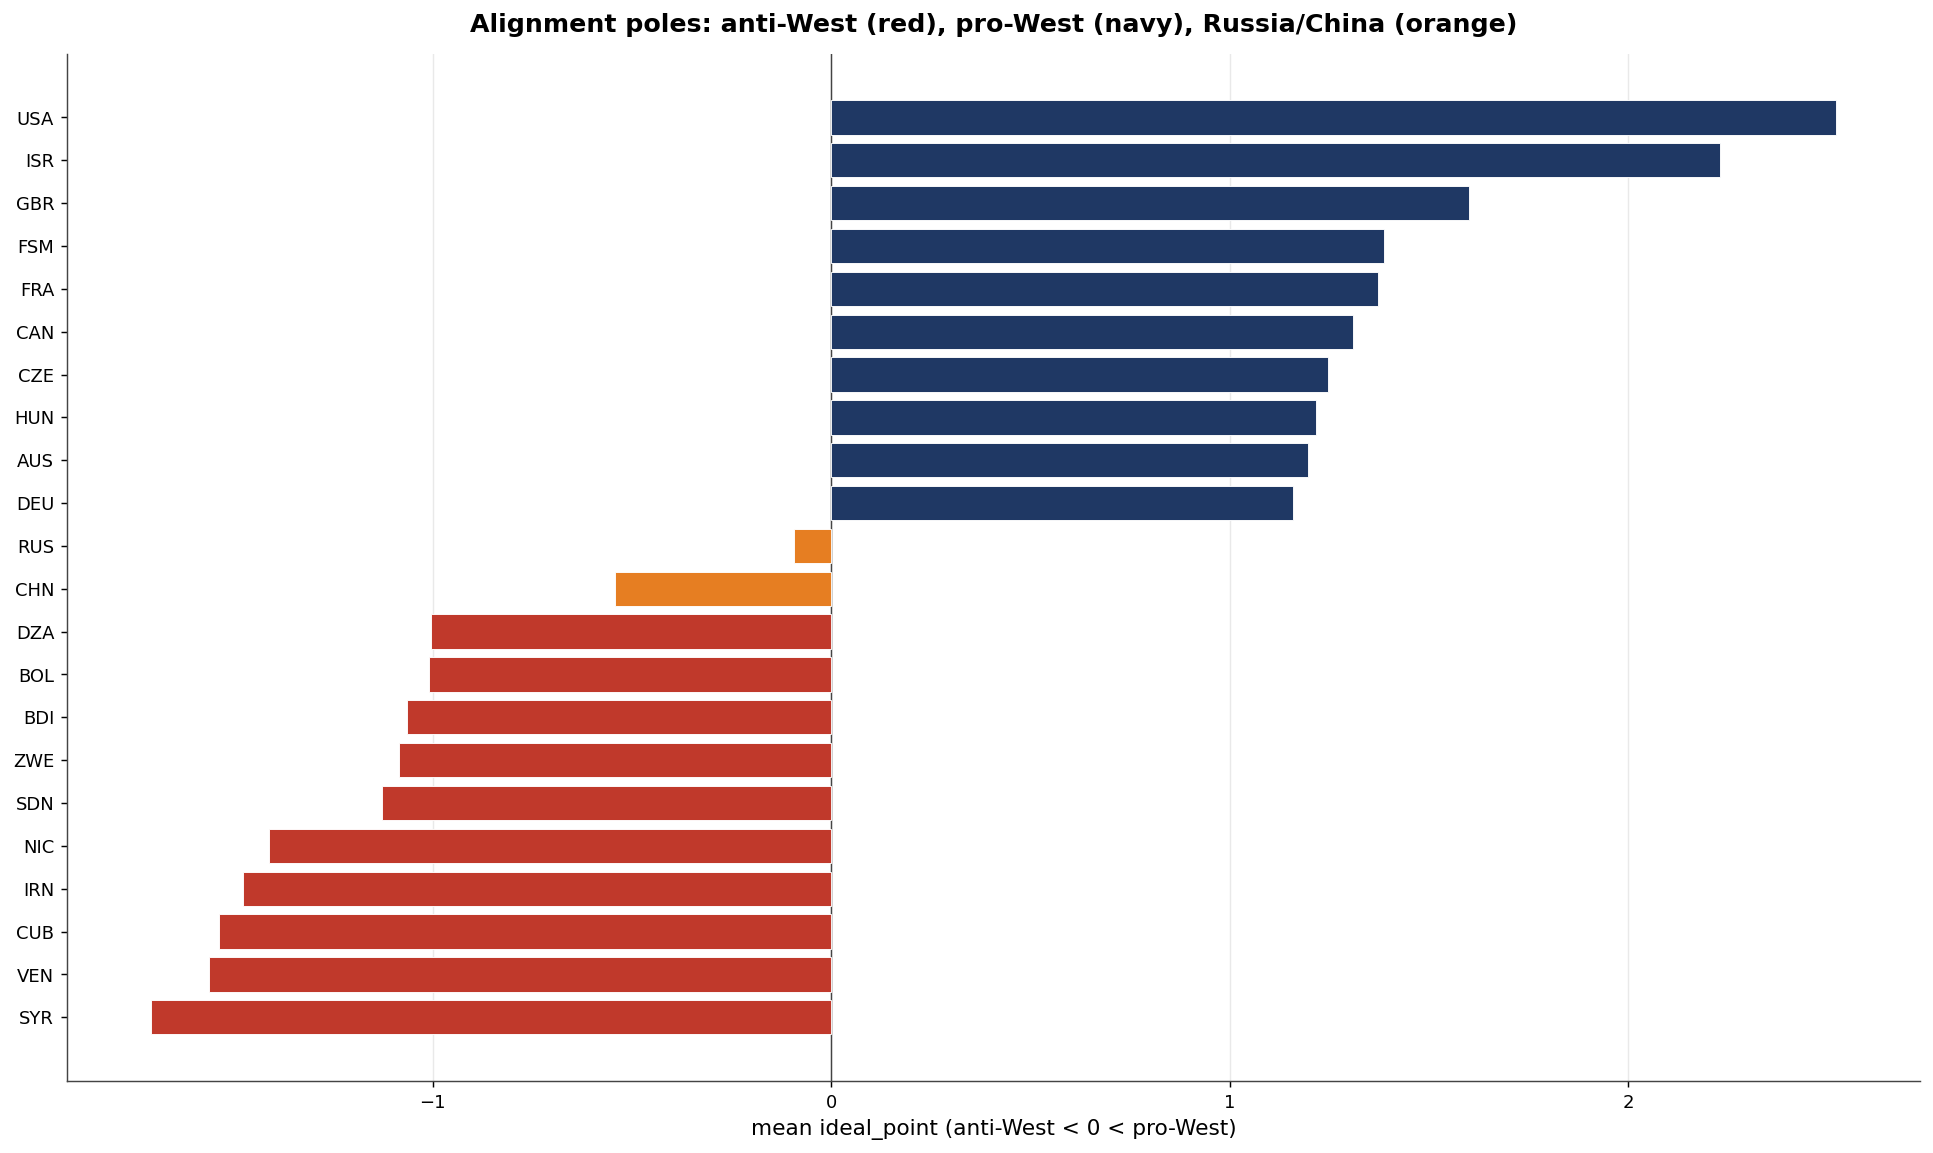

In [11]:
mi = unga.groupby('iso3')['ideal_point'].mean().sort_values()
ref = ['RUS', 'CHN']
ends = pd.concat([mi.head(10), mi[mi.index.isin(ref)], mi.tail(10)])
ends = ends[~ends.index.duplicated()].sort_values()
def barcol(code, v):
    if code in ref:
        return '#E67E22'
    return RED if v < 0 else NAVY
colors = [barcol(c, v) for c, v in ends.items()]
fig, ax = plt.subplots(figsize=(15, 9))
ax.barh(ends.index, ends.values, color=colors, edgecolor='white', linewidth=0.5, zorder=3)
ax.axvline(0, color='#444444', lw=0.8)
ax.set_xlabel('mean ideal_point (anti-West < 0 < pro-West)')
ax.set_title('Alignment poles: anti-West (red), pro-West (navy), Russia/China (orange)', pad=12)
ax.grid(axis='y', visible=False); fig.tight_layout(); plt.show()

The most anti-Western countries are Syria, Venezuela, Cuba, Iran, Nicaragua and Sudan. The most pro-Western are the USA, Israel, the UK, Micronesia, France and Canada. Russia and China sit near the middle, not at the extremes, they vote moderately on many procedural and development resolutions.

## 5. Validate and Save

I check the final country-year table for duplicate iso3-year keys and report missing values (the self-pole NaNs and the unscored 2025 session are expected) before saving.

In [13]:
print('rows:', len(unga), '| countries:', unga.iso3.nunique(), '| years:', unga.year.min(), '-', unga.year.max())
print('duplicate iso3-year keys:', int(unga.duplicated(['iso3', 'year']).sum()))
unga.isna().sum().to_frame('n_missing')

rows: 2115 | countries: 193 | years: 2015 - 2025
duplicate iso3-year keys: 0


,n_missing
iso3,0
year,0
ideal_point,0
agree_us,200
agree_rus,200
n_votes,0


The table is clean: 2,115 country-years across 193 countries, 2015 to 2025, with no duplicate iso3-year keys. ideal_point and n_votes are fully populated. agree_us and agree_rus each have 200 NaN.

I confirm the keys are unique and save the clean per-country-year alignment table.

In [14]:
assert unga.duplicated(['iso3', 'year']).sum() == 0, 'duplicate iso3-year keys!'
os.makedirs(OUT_DIR, exist_ok=True)
path = f'{OUT_DIR}/ungavoting_clean.csv'
unga.to_csv(path, index=False)
print('saved:', path, '|', unga.shape, '| countries:', unga.iso3.nunique())
unga.head()

saved: /Users/oussamaennaciri/Documents/Education/Academique/Regis/MSDS692 S40 Data Science Practicum/data/interim/ungavoting/ungavoting_clean.csv | (2115, 6) | countries: 193


,iso3,year,ideal_point,agree_us,agree_rus,n_votes
0,AFG,2015,-0.740889,0.308989,0.741573,73
1,AFG,2016,-0.811797,0.458716,0.676190,73
2,AFG,2017,-0.770687,0.318966,0.659483,85
3,AFG,2018,-0.768278,0.267123,0.693878,95
4,AFG,2019,-0.496914,0.248175,0.687500,91


Claude (Anthropic) was used only as a collaborator for writing code and polishing the notebooks. All analytical decisions, interpretations, and research were conducted independently by me.